# Netback

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src import config as c, data, netback

pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.figsize": (10, 3), "axes.grid": True, "grid.alpha": .3})

In [2]:
c.ROUTES

{'tokyo': {'price': 'JKM',
  'freight': 'BLNG3',
  'laden_days': 20,
  'canal_usd': 1000000,
  'regas_usd_mmbtu': 0.0},
 'rotterdam': {'price': 'TTF',
  'freight': 'BLNG2',
  'laden_days': 10,
  'canal_usd': 0,
  'regas_usd_mmbtu': 0.5}}

In [3]:
{"cargo_mmbtu": c.CARGO_MMBTU, "boil_off_per_day": c.BOIL_OFF_PER_DAY, "round_trip": c.ROUND_TRIP,
 "port_days": c.PORT_DAYS, "port_cost_usd": c.PORT_COST_USD, "mmbtu_per_mwh": c.MMBTU_PER_MWH}

{'cargo_mmbtu': 3500000,
 'boil_off_per_day': 0.0015,
 'round_trip': 2,
 'port_days': 2,
 'port_cost_usd': 200000,
 'mmbtu_per_mwh': 3.412142}

## Inputs

In [4]:
tokyo = data.dataset("tokyo")
rotterdam = data.dataset("rotterdam")

In [5]:
tokyo.shape, rotterdam.shape

((257, 10), (242, 13))

In [6]:
tokyo.tail(3)

,asof_utc,dest_contract,dest_trade_date,dest_settle,dest_settle_utc,freight_contract,freight_trade_date,freight_settle,freight_settle_utc,staleness_days
trade_date,,,,,,,,,,
2026-01-28,2026-01-28 22:00:00+00:00,JKMH2026,2026-01-28,11.350,2026-01-28 08:30:00+00:00,BLNG3G2026,2026-01-28,"42,250.000",2026-01-28 16:00:00+00:00,0
2026-01-29,2026-01-29 22:00:00+00:00,JKMH2026,2026-01-29,11.465,2026-01-29 08:30:00+00:00,BLNG3G2026,2026-01-29,"42,250.000",2026-01-29 16:00:00+00:00,0
2026-01-30,2026-01-30 22:00:00+00:00,JKMH2026,2026-01-30,11.525,2026-01-30 08:30:00+00:00,BLNG3G2026,2026-01-30,"42,250.000",2026-01-30 16:00:00+00:00,0


In [7]:
rotterdam.tail(3)

,asof_utc,dest_contract,dest_trade_date,dest_settle,dest_settle_utc,freight_contract,freight_trade_date,freight_settle,freight_settle_utc,fx_trade_date,eurusd,fx_available_utc,staleness_days
trade_date,,,,,,,,,,,,,
2026-02-02,2026-02-02 22:00:00+00:00,TTFH2026,2026-02-02,33.945,2026-02-02 16:00:00+00:00,BLNG2H2026,2026-02-02,"14,500.000",2026-02-02 16:00:00+00:00,2026-02-01,1.179,2026-02-02 22:00:00+00:00,1
2026-02-03,2026-02-03 22:00:00+00:00,TTFH2026,2026-02-03,32.860,2026-02-03 16:00:00+00:00,BLNG2H2026,2026-02-03,"14,500.000",2026-02-03 16:00:00+00:00,2026-02-02,1.182,2026-02-03 22:00:00+00:00,1
2026-02-04,2026-02-04 22:00:00+00:00,TTFH2026,2026-02-04,33.501,2026-02-04 16:00:00+00:00,BLNG2H2026,2026-02-04,"14,500.000",2026-02-04 16:00:00+00:00,2026-02-03,1.181,2026-02-04 22:00:00+00:00,1


## Calculation

In [8]:
# netback = dest_price - boiloff - regas - freight - canal - port        USD per loaded MMBtu
nb_tokyo = netback.netback("tokyo", tokyo)
nb_rotterdam = netback.netback("rotterdam", rotterdam)

In [9]:
nb_tokyo.tail(3)

,dest_price,boiloff,regas,freight,canal,port,netback
trade_date,,,,,,,
2026-01-28,11.350,0.336,0.000,0.507,0.286,0.057,10.164
2026-01-29,11.465,0.339,0.000,0.507,0.286,0.057,10.276
2026-01-30,11.525,0.341,0.000,0.507,0.286,0.057,10.334


In [10]:
nb_rotterdam.tail(3)

,dest_price,boiloff,regas,freight,canal,port,netback
trade_date,,,,,,,
2026-02-02,11.728,0.175,0.493,0.091,0.000,0.057,10.912
2026-02-03,11.379,0.170,0.493,0.091,0.000,0.057,10.569
2026-02-04,11.591,0.173,0.493,0.091,0.000,0.057,10.777


In [11]:
# the last Tokyo row by hand: what arrives after boil-off, less the ship, the canal and the ports
row, r = tokyo.iloc[-1], c.ROUTES["tokyo"]
delivered = (1 - c.BOIL_OFF_PER_DAY) ** r["laden_days"]
freight = row["freight_settle"] * (r["laden_days"] * c.ROUND_TRIP + c.PORT_DAYS) / c.CARGO_MMBTU
row["dest_settle"] * delivered - freight - (r["canal_usd"] + c.PORT_COST_USD) / c.CARGO_MMBTU, nb_tokyo["netback"].iloc[-1]

(np.float64(10.334275733536602), np.float64(10.334275733536604))

In [12]:
# the last Rotterdam row by hand: TTF through the FX and the MWh, regas on what arrives
row, r = rotterdam.iloc[-1], c.ROUTES["rotterdam"]
delivered = (1 - c.BOIL_OFF_PER_DAY) ** r["laden_days"]
dest = row["dest_settle"] * row["eurusd"] / c.MMBTU_PER_MWH
freight = row["freight_settle"] * (r["laden_days"] * c.ROUND_TRIP + c.PORT_DAYS) / c.CARGO_MMBTU
(dest - r["regas_usd_mmbtu"]) * delivered - freight - c.PORT_COST_USD / c.CARGO_MMBTU, nb_rotterdam["netback"].iloc[-1]

(np.float64(10.777120633364213), np.float64(10.777120633364213))

In [13]:
# the cost of delivery on each route, mean over the dates both price
both = nb_tokyo.index.intersection(nb_rotterdam.index)
stack = pd.DataFrame({"tokyo": nb_tokyo.loc[both].mean(), "rotterdam": nb_rotterdam.loc[both].mean()})
stack

,tokyo,rotterdam
dest_price,11.841,11.657
boiloff,0.350,0.174
regas,0.000,0.493
freight,0.520,0.221
canal,0.286,0.000
port,0.057,0.057
netback,10.628,10.713


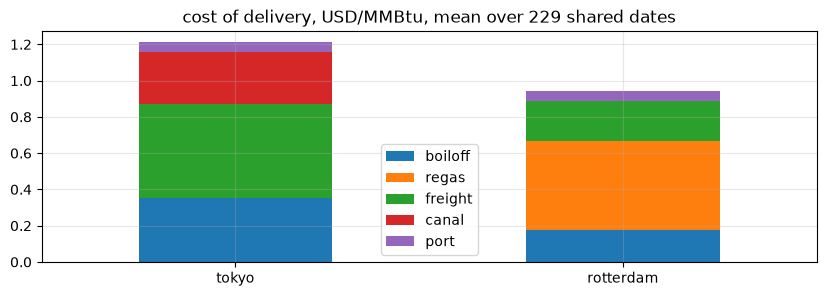

In [14]:
costs = ["boiloff", "regas", "freight", "canal", "port"]
stack.loc[costs].T.plot.bar(stacked=True, rot=0, title=f"cost of delivery, USD/MMBtu, mean over {len(both)} shared dates");

## Validation

In [15]:
nb_tokyo.index.is_unique, nb_rotterdam.index.is_unique

(True, True)

In [16]:
nb_tokyo.isna().sum().sum(), nb_rotterdam.isna().sum().sum()

(np.int64(0), np.int64(0))

In [17]:
# the identity holds row by row
(nb_tokyo["netback"] - (nb_tokyo["dest_price"] - nb_tokyo[costs].sum(axis=1))).abs().max()

np.float64(1.7763568394002505e-15)

In [18]:
(nb_tokyo["dest_price"] > 0).all(), (nb_rotterdam["dest_price"] > 0).all()

(np.True_, np.True_)

In [19]:
(nb_tokyo["netback"] < nb_tokyo["dest_price"]).all(), (nb_rotterdam["netback"] < nb_rotterdam["dest_price"]).all()

(np.True_, np.True_)

In [20]:
# every input on a row was readable at its anchor
(tokyo[["dest_settle_utc", "freight_settle_utc"]].le(tokyo["asof_utc"], axis=0).all().all(),
 rotterdam[["dest_settle_utc", "freight_settle_utc", "fx_available_utc"]].le(rotterdam["asof_utc"], axis=0).all().all())

(np.True_, np.True_)

In [21]:
# and none older than the tolerance
tokyo["staleness_days"].max(), rotterdam["staleness_days"].max(), c.TOLERANCE

(np.int64(1), np.int64(4), '5D')

In [22]:
# units: once TTF is in USD/MMBtu the two destination prices sit in one range
pd.DataFrame({"tokyo": nb_tokyo["dest_price"].describe(), "rotterdam": nb_rotterdam["dest_price"].describe()})

,tokyo,rotterdam
count,257.000,242.000
mean,12.042,11.692
std,1.500,1.592
min,9.285,9.117
25%,11.150,10.785
50%,11.660,11.371
75%,13.085,12.181
max,16.840,17.539


In [23]:
# the cost of delivery as a share of the destination price
(stack.loc[costs].sum() / stack.loc["dest_price"]).round(3)

tokyo       0.102
rotterdam   0.081
dtype: float64

## Arb

In [24]:
# arb > 0: Tokyo outbids Rotterdam for the cargo. arb < 0: Rotterdam outbids Tokyo
arb = (nb_tokyo["netback"] - nb_rotterdam["netback"]).dropna().rename("arb")  # the dates both routes price
arb.tail()

trade_date
2026-01-26   -2.726
2026-01-27   -2.662
2026-01-28   -2.605
2026-01-29   -2.945
2026-01-30   -2.747
Name: arb, dtype: float64

In [25]:
arb.describe()

count   229.000
mean     -0.084
std       0.677
min      -2.945
25%      -0.213
50%       0.018
75%       0.251
max       1.530
Name: arb, dtype: float64

In [26]:
(arb > 0).mean()  # share of dates Tokyo wins

np.float64(0.5240174672489083)

In [27]:
# how often the routing decision flips
(arb.gt(0) != arb.gt(0).shift()).sum() - 1

np.int64(36)

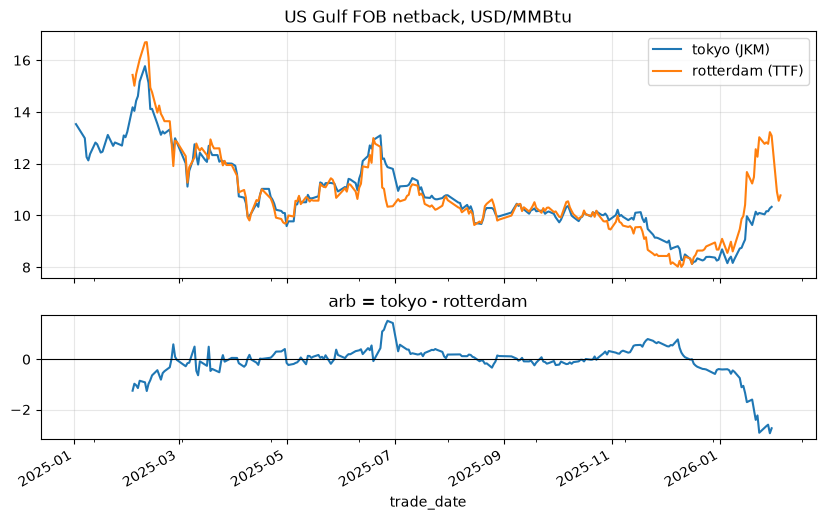

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
nb_tokyo["netback"].plot(ax=axes[0], label="tokyo (JKM)")
nb_rotterdam["netback"].plot(ax=axes[0], label="rotterdam (TTF)")
axes[0].set_title("US Gulf FOB netback, USD/MMBtu"); axes[0].legend()
arb.plot(ax=axes[1], title="arb = tokyo - rotterdam"); axes[1].axhline(0, color="k", lw=.8);

In [29]:
# the widest spreads either way
pd.concat([arb.nlargest(3), arb.nsmallest(3)])

trade_date
2025-06-27    1.530
2025-06-30    1.443
2025-06-26    1.380
2026-01-29   -2.945
2026-01-23   -2.925
2026-01-30   -2.747
Name: arb, dtype: float64

In [30]:
# what turns the mean decision: the BLNG3 fall, in USD/day, that closes the average gap, against its mean
days = c.ROUTES["tokyo"]["laden_days"] * c.ROUND_TRIP + c.PORT_DAYS
round(-arb.mean() * c.CARGO_MMBTU / days), round(tokyo["freight_settle"].mean())

(7040, 43492)

## Final output

In [31]:
# where each route stands on its last trade date
last = pd.DataFrame({f"tokyo {nb_tokyo.index[-1]:%Y-%m-%d}": nb_tokyo.iloc[-1],
                     f"rotterdam {nb_rotterdam.index[-1]:%Y-%m-%d}": nb_rotterdam.iloc[-1]})
last

,tokyo 2026-01-30,rotterdam 2026-02-04
dest_price,11.525,11.591
boiloff,0.341,0.173
regas,0.000,0.493
freight,0.507,0.091
canal,0.286,0.000
port,0.057,0.057
netback,10.334,10.777


In [32]:
out = pd.DataFrame({"netback_tokyo": nb_tokyo["netback"], "netback_rotterdam": nb_rotterdam["netback"],
                    "arb": arb}).dropna()
out.tail(10)

,netback_tokyo,netback_rotterdam,arb
trade_date,,,
2026-01-16,9.972,11.679,-1.707
2026-01-19,9.633,11.236,-1.604
2026-01-21,10.147,12.561,-2.414
2026-01-22,10.035,12.271,-2.236
2026-01-23,10.098,13.024,-2.925
2026-01-26,10.043,12.769,-2.726
2026-01-27,10.164,12.826,-2.662
2026-01-28,10.164,12.769,-2.605
2026-01-29,10.276,13.221,-2.945


In [33]:
out.shape, out.index.min(), out.index.max()

((229, 3), Timestamp('2025-02-03 00:00:00'), Timestamp('2026-01-30 00:00:00'))